### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, precision_score,
                             recall_score, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

### Load Data & Train/Test Split

In [2]:
df = pd.read_csv('D:/Projects/predictiq/data/master_features.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# Time-based split — CRITICAL for time series
# Train on first 9 months, test on last 3 months
# Never use random split on time series data — it leaks future info

split_date = pd.Timestamp('2015-10-01')

train = df[df['datetime'] < split_date]
test  = df[df['datetime'] >= split_date]

feature_cols = [c for c in df.columns if c not in ['datetime', 'machineID', 'label']]

X_train = train[feature_cols]
y_train = train['label']
X_test  = test[feature_cols]
y_test  = test['label']

print(f"Train size : {X_train.shape} | Failure rate: {y_train.mean()*100:.2f}%")
print(f"Test size  : {X_test.shape}  | Failure rate: {y_test.mean()*100:.2f}%")
print(f"Features   : {len(feature_cols)}")

Train size : (654600, 34) | Failure rate: 2.01%
Test size  : (221500, 34)  | Failure rate: 1.83%
Features   : 34


### Define Evaluation Function

In [3]:
def evaluate_model(name, model, X_test, y_test, threshold=0.5):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)
    
    auc    = roc_auc_score(y_test, y_prob)
    f1     = f1_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    
    print(f"\n{'='*50}")
    print(f" {name}")
    print(f"{'='*50}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Failure', 'Failure'],
                yticklabels=['No Failure', 'Failure'])
    plt.title(f'{name} — Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    return {'model': name, 'auc': auc, 'f1': f1, 'precision': prec, 'recall': rec}

### Setup MLflow

In [4]:
mlflow.set_experiment("predictive_maintenance")

print("MLflow experiment set.")
print("Run 'mlflow ui' in terminal to view the dashboard at http://localhost:5000")

2026/03/01 14:34:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/01 14:34:05 INFO mlflow.store.db.utils: Updating database tables
2026/03/01 14:34:07 INFO mlflow.tracking.fluent: Experiment with name 'predictive_maintenance' does not exist. Creating a new experiment.


MLflow experiment set.
Run 'mlflow ui' in terminal to view the dashboard at http://localhost:5000


###  Model 1: Random Forest (Baseline)

Class imbalance ratio: 48.8x

 Random Forest
  ROC-AUC   : 1.0000
  F1 Score  : 0.9952
  Precision : 0.9948
  Recall    : 0.9956

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    217450
           1       0.99      1.00      1.00      4050

    accuracy                           1.00    221500
   macro avg       1.00      1.00      1.00    221500
weighted avg       1.00      1.00      1.00    221500



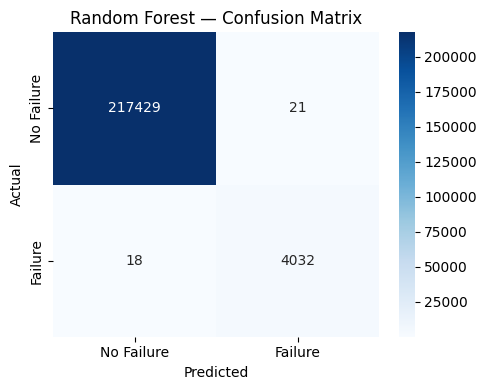

2026/03/01 14:36:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 14:36:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest logged to MLflow.


In [5]:
# Class imbalance ratio for weighting
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos
print(f"Class imbalance ratio: {scale:.1f}x")

with mlflow.start_run(run_name="RandomForest_baseline"):
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        class_weight='balanced',   # handles imbalance
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    
    results_rf = evaluate_model("Random Forest", rf, X_test, y_test)
    
    # Log to MLflow
    mlflow.log_params({
        'n_estimators': 100,
        'max_depth': 10,
        'class_weight': 'balanced'
    })
    mlflow.log_metrics({
        'auc': results_rf['auc'],
        'f1': results_rf['f1'],
        'precision': results_rf['precision'],
        'recall': results_rf['recall']
    })
    mlflow.sklearn.log_model(rf, "random_forest_model")
    
print("\nRandom Forest logged to MLflow.")

### Model 2: XGBoost


 XGBoost
  ROC-AUC   : 1.0000
  F1 Score  : 0.9925
  Precision : 0.9863
  Recall    : 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    217450
           1       0.99      1.00      0.99      4050

    accuracy                           1.00    221500
   macro avg       0.99      1.00      1.00    221500
weighted avg       1.00      1.00      1.00    221500



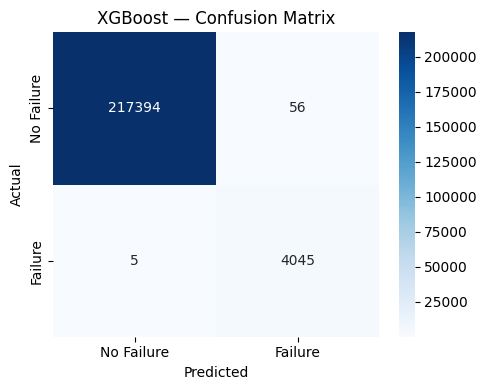

2026/03/01 14:36:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost logged to MLflow.


In [6]:
with mlflow.start_run(run_name="XGBoost"):
    xgb = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,    # handles imbalance
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    )
    xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False
    )
    
    results_xgb = evaluate_model("XGBoost", xgb, X_test, y_test)
    
    mlflow.log_params({
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'scale_pos_weight': round(scale, 2)
    })
    mlflow.log_metrics({
        'auc': results_xgb['auc'],
        'f1': results_xgb['f1'],
        'precision': results_xgb['precision'],
        'recall': results_xgb['recall']
    })
    mlflow.xgboost.log_model(xgb, "xgboost_model")

print("\nXGBoost logged to MLflow.")

### Model 3: LightGBM


 LightGBM
  ROC-AUC   : 1.0000
  F1 Score  : 0.9936
  Precision : 0.9885
  Recall    : 0.9988

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    217450
           1       0.99      1.00      0.99      4050

    accuracy                           1.00    221500
   macro avg       0.99      1.00      1.00    221500
weighted avg       1.00      1.00      1.00    221500



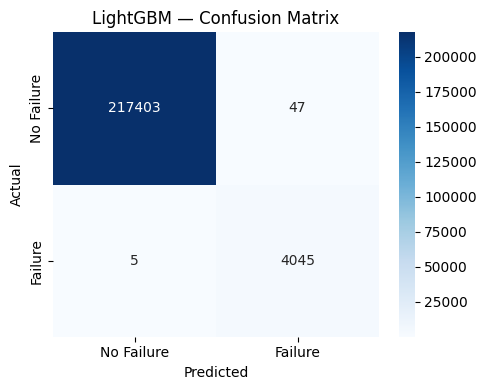

2026/03/01 14:36:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/01 14:36:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM logged to MLflow.


In [7]:
with mlflow.start_run(run_name="LightGBM"):
    lgbm = LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=scale,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgbm.fit(X_train, y_train)
    
    results_lgbm = evaluate_model("LightGBM", lgbm, X_test, y_test)
    
    mlflow.log_params({
        'n_estimators': 300,
        'max_depth': 6,
        'learning_rate': 0.05,
        'scale_pos_weight': round(scale, 2)
    })
    mlflow.log_metrics({
        'auc': results_lgbm['auc'],
        'f1': results_lgbm['f1'],
        'precision': results_lgbm['precision'],
        'recall': results_lgbm['recall']
    })
    mlflow.sklearn.log_model(lgbm, "lightgbm_model")

print("\nLightGBM logged to MLflow.")

### Model Comparison


Model Comparison:


,model,auc,f1,precision,recall
0,Random Forest,0.999987,0.995187,0.994819,0.995556
1,LightGBM,0.999985,0.993613,0.988514,0.998765
2,XGBoost,0.999985,0.992516,0.986345,0.998765


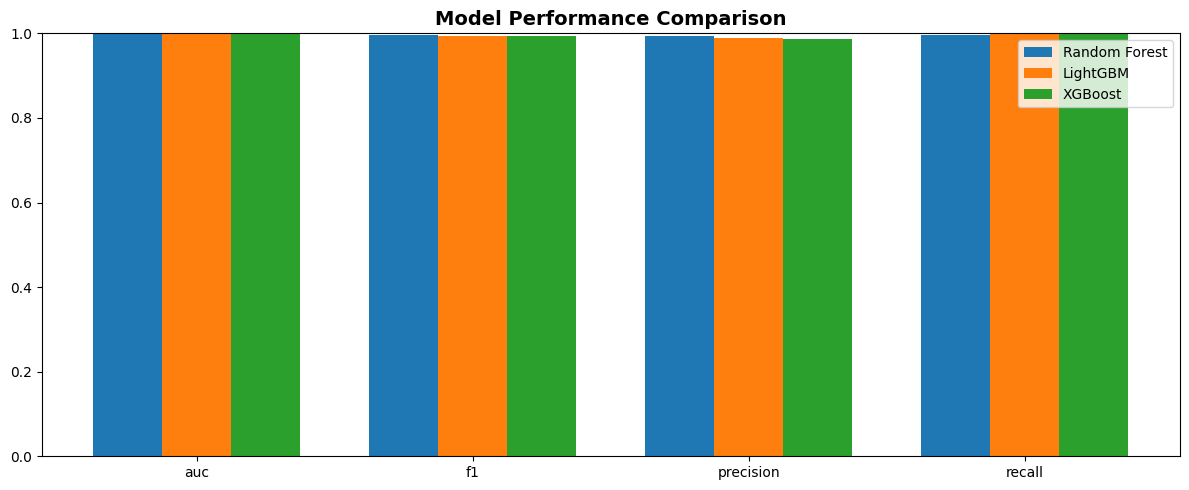

In [8]:
results = pd.DataFrame([results_rf, results_xgb, results_lgbm])
results = results.sort_values('auc', ascending=False).reset_index(drop=True)

print("\nModel Comparison:")
display(results)

# Bar chart comparison
metrics = ['auc', 'f1', 'precision', 'recall']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
for i, (_, row) in enumerate(results.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metrics], width, label=row['model'])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Feature Importance (Best Model)

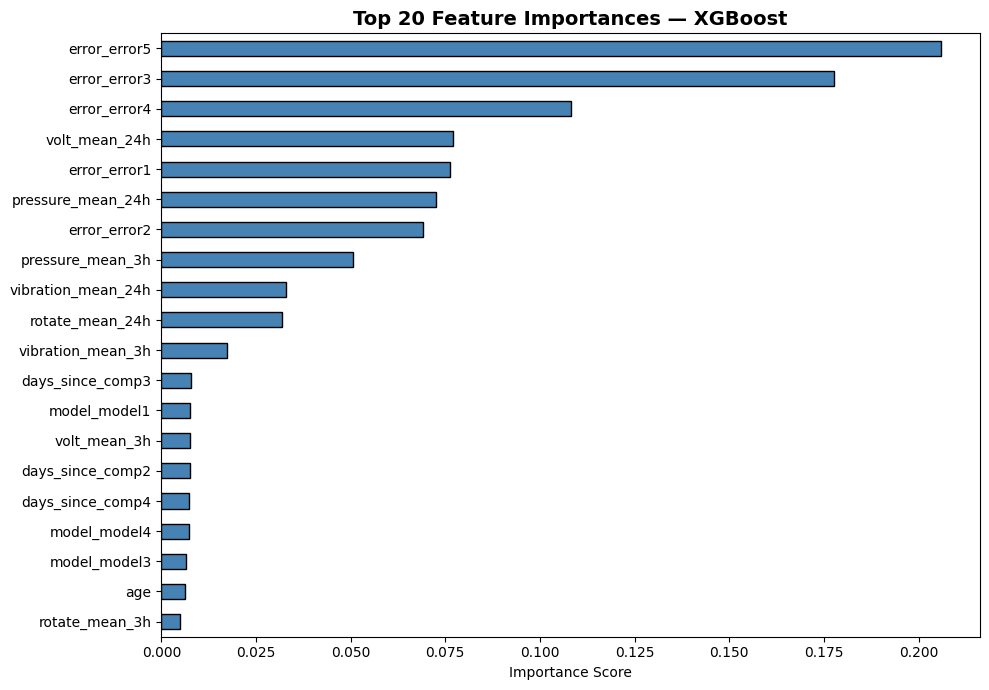

In [9]:
# Plot feature importance for XGBoost
feat_imp = pd.Series(xgb.feature_importances_, index=feature_cols)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### ROC Curve Comparison

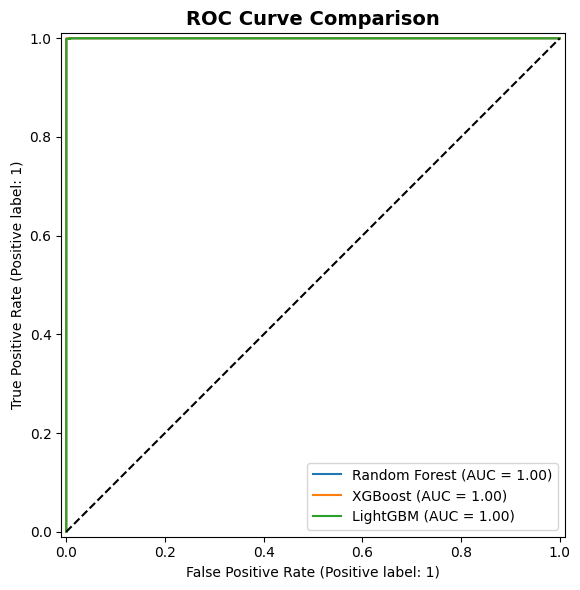

In [10]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in [("Random Forest", rf), ("XGBoost", xgb), ("LightGBM", lgbm)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)

ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.plot([0,1], [0,1], 'k--', label='Random')
plt.tight_layout()
plt.show()